# Introduction

This project focuses on creating visuals using seaborn and matplot library. The data is a mock up on National Parks Data with two different CV's: observations and species. The questions I would like to answer using the data sets are: 
1. How many species hold a conservation status?
2. Of the species holding a conservation status, what is the proportional breakdown of the conservation status'?
3. How are the animal categories distributed between the four National Parks -- does any National Park in particular show more of one category compared to the othes?
4. Are there any species that may be more likely to hold a conservation status? And are the differences, if any, statistically significant?

The data sources were provided by Codecademy.com and are fictional data sets. 

The first part of data analysis is importing the correct libraries and reading the two provided datasets. I have saved the two data sets in species and observations accordingly.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

observations = pd.read_csv('observations.csv')
species = pd.read_csv('species_info.csv')

The first CSV that we will investigate is species. Using .head(), we will observe the first 5 rows. We will also use .info() to get a preliminary understanding of this first data set.

In [2]:
print(species.head())
species.info()

  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...                 NaN  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)                 NaN  
4                                      Wapiti Or Elk                 NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      

We will use the same code to investigate our second CSV, observations. 

In [3]:
print(observations.head())
observations.info()

            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB


Now that the two CSV's have preliminarily been investigated, I will begin to make some dataframes that I think will be useful as we continue our data analysis. For when I want to investigate the species and conservation status amonst the National Parks I will create a combined dataframe that include both CSV's. I will also create separate dataframes for each National Park for when I want to do analysis on individual parks. Lastly I will create an array for when I want to analyze each park using a for loop rather than writing repeats of code for each park. I could easily also use the existing data frames instead of making separate ones -- its just a matter of preference. 

In [4]:
combined_df = pd.merge(observations, species, how='outer')
BNP = combined_df[combined_df.park_name == 'Bryce National Park']
YE = combined_df[combined_df.park_name == 'Yellowstone National Park']
GS = combined_df[combined_df.park_name == 'Great Smoky Mountains National Park']
YO = combined_df[combined_df.park_name == 'Yosemite National Park']
park_df = [BNP, YE, GS, YO]

The first question I want to answer is: how many of the observed species hold a conservation status amongst all of the National Parks included. From my initial investigation into the observations CSV, I know that there are species that hold a conservation status of NaN. Based on the other types of conservation status (Species of Concern, Endangered, Threatened, and In Recovery), we can assume that the NaN represents no conservation status. Here I use .isna().sum() to find the number of species that hold no conservation status and store it in the variable na_values. Then I use len() of my dataframe minus na_values to find the number of rows that do not have Nan as their conservation status. I use plt.bar() to graph this as I am handling categorical data rather than just quantitative. 

The next question I want to answer is: What is the percentile breakdown? 

To answer thsi question I am going to use the data set without Nan values using .dropna() and then finding the counts of each conservation status using .value_counts(). I use plot.pie() to graph the conservation status breakdown with a funtion make_autopct() that creates the percentage labels in the format I would like. I pulled make_autopct and my_autopct from another user's data analysis.

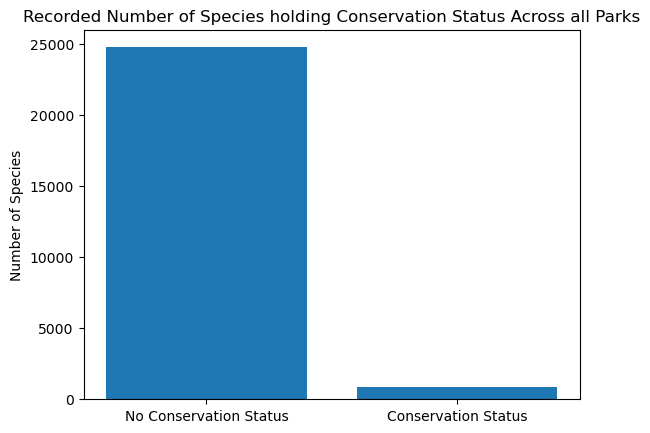

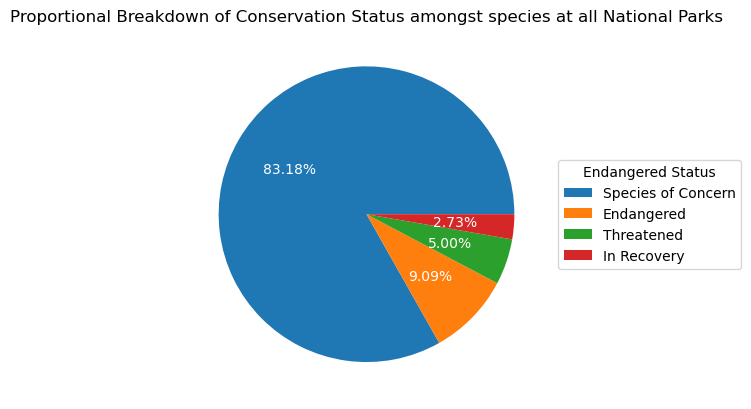

<Figure size 640x480 with 0 Axes>

In [5]:
na_values = combined_df.conservation_status.isna().sum() 
non_na = len(combined_df) - na_values
plt.bar(['No Conservation Status', 'Conservation Status'], [na_values, non_na])
plt.title('Recorded Number of Species holding Conservation Status Across all Parks')
plt.ylabel('Number of Species')
plt.show()
plt.clf()

combined_df_nona = combined_df.dropna()
values = combined_df_nona.conservation_status.value_counts(normalize=True)


def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.2f}%'.format(p=pct,v=val) 
    return my_autopct


status_labels = ['Species of Concern', 'Endangered', 'Threatened', 'In Recovery']
values.plot.pie(autopct=make_autopct(values), textprops={'color':'w'}, labels=None)
plt.title('Proportional Breakdown of Conservation Status amongst species at all National Parks')
plt.legend(status_labels, title='Endangered Status', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
plt.ylabel('') 
plt.show()
plt.clf()

The next question I would like to address is how are the animal categories distributed across the four National Parks. Since this data set is fictional, the counts of each species category is equal amongst all National Parks. To preserve the analysis integrity we created the graphs as if the data was not equal across all National Parks. 

The first step for this portion of the data analysis was to create a custom function category_observations() that take a single argument. When a dataframe is passed into the function, it returns the number of observations for each animal category within the data frame passed in. 

From there I decide I want to create a bar graph for each of the National Parks in one figure, so I create a single figure with 2 rows and 2 columns that I will fill with my completed graphs. 

Then I use a for loop to iterate through my park_df which contains every individual park dataframe and create a bargraph with the data from calling category_observations. I append the count for each animal category to an empty array all_y, and each animal cateogry to an empty array all_x. I use plt.subplots_adjust() to adjust the space around each graph so that all the bar graphs are visible. 

I could stop here but I chose to create a second type of bar graph that includes all the data in a single graph verus each park data in inidividual graphs. To do this I use my existing all_x and all_y dataframes to access each individual National Parks data and call plt.bar() for each dataset. First I use variable x to tell the program that I will have 7 categories that I will need to fill in data for. When I call the first set of bars for the first park, I set its location at the first tick. From then, when I call each subsequent bar, I set its location to x plus the width of the previous bar so that the bars are aligned and visible. I set the width of the bar to a single number 0.2, and then play around a little bit with the axis to get the image I want. 

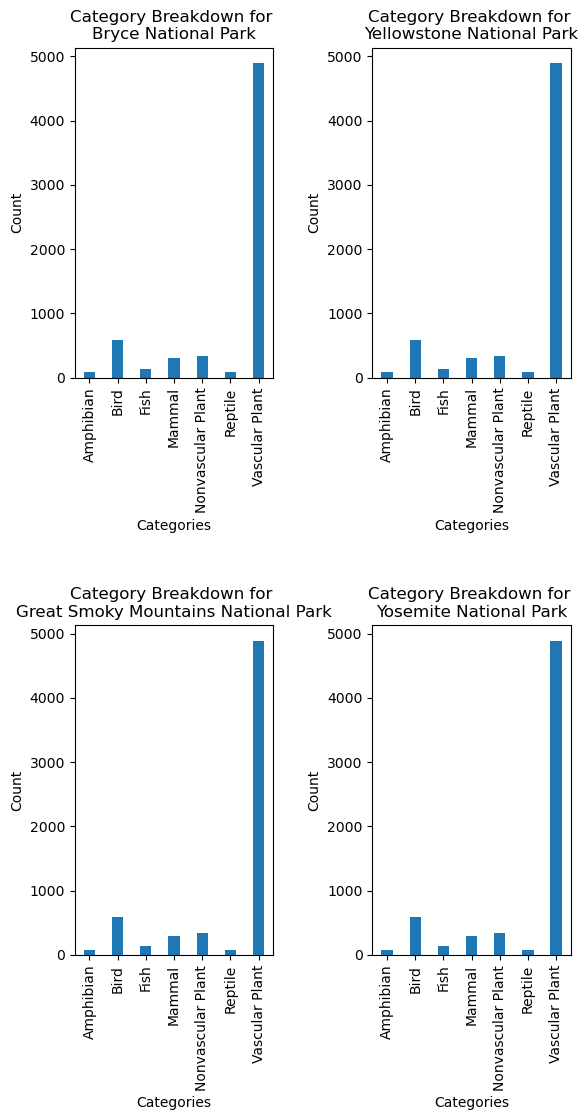

7


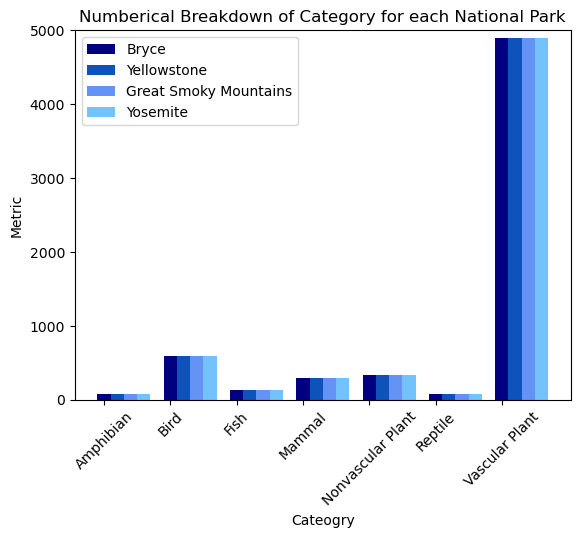

In [6]:
def category_observations(df): 
    var = df.groupby('category').observations.size()
    x_values = sorted(df.category.unique())
    y_values = []
    for item in var: 
        y_values.append(item)
    return ([x_values, y_values])

all_x = []
all_y = []

plt.figure()
col_value = 2
row_value = 2
fig_num = 1
width = 0.4

for park in park_df: 
    all_x.append(category_observations(park)[0])
    all_y.append(category_observations(park)[1])     
    plt.subplot(col_value, row_value, fig_num)
    plt.bar(all_x[0], all_y[0], width)
    plt.ylabel('Count')
    plt.xlabel('Categories')
    plt.title('Category Breakdown for \n' +park.park_name.iloc[0])
    plt.xticks(rotation=90)
    fig_num+=1
plt.subplots_adjust(top=2, hspace=0.75, wspace=0.5)
plt.show()
plt.clf()

length = len(all_y[0])
print(length)
x=np.arange(length)
x_labels = all_x[0]
width = 0.2
plt.bar(x, all_y[0], width, color='#000080', label='Bryce')
plt.bar(x+width, all_y[1], width, color='#0F52BA', label='Yellowstone')
plt.bar(x+(2*width), all_y[2], width, color='#6593F5', label='Great Smoky Mountains')
plt.bar(x+(3*width), all_y[3], width, color='#73C2FB', label='Yosemite')

plt.ylabel('Metric')
plt.ylim(0,5000)
plt.xticks(x, labels=x_labels, rotation=45)
plt.xlabel('Cateogry')
plt.title('Numberical Breakdown of Category for each National Park')
plt.legend()
plt.show()

The next question I will answer is -- is any one animal category more likely to hold an endagnered status over others -- and is this entirely due to chance or is it statistically significant. 

First i want to see which animal categories appear to hold no conservation status -- or whose value is not equivalent to a string as each conservation status is a string and the Nan values are those holding no conservation status. From there I group the data by conservation_status and animal category, and then count the number of species for each animal category for each conservation status. 
.unstack() helps visualize the data better and allows us to view where data might be missing whereas .count() only shows what data is available. 

In [7]:
conservation_category = species[species.conservation_status != str]\
.groupby(["conservation_status", "category"])['scientific_name'].count().unstack()

conservation_category

category,Amphibian,Bird,Fish,Mammal,Nonvascular Plant,Reptile,Vascular Plant
conservation_status,,,,,,,
Endangered,1.0,4.0,3.0,7.0,NaN,NaN,1.0
In Recovery,NaN,3.0,NaN,1.0,NaN,NaN,NaN
Species of Concern,4.0,72.0,4.0,28.0,5.0,5.0,43.0
Threatened,2.0,NaN,4.0,2.0,NaN,NaN,2.0


As a reminder, the table visualized above shows the number of species within each animal category that DOES NOT have a given conservation status. Thus, we can assume that NaN indicates animal categories that all hold a conservation status. 

I create a new column called 'protected' that is filled with True where a row includes a species that holds a conservation status and false for rows that have NaN as their conservation status -- so no conservation status. 

From here I will create a new dataframe that groupes my species data frame by category and protectected. I will then count the number of unique scientific_names for each animal category and protected status (True and False). This will give me an idea of how many species within in each animal category is either protected or not (holds conservation status or not)

I will then use reset_index() to turn the series into its own dataframe. Additonally the reset_index() will also do as it says and reset the index. I will create a new df by using .pivot() to reorganize my data. I could optionally call .pivot after reset_index() on category counts rather than storing the pivot table in a new dataframe. This pivot table will have columns of the animal category and then true or false based on the value stored in the protected column. For ease, I will then rename the columns so that false is not_protected and trye is protected. 


In [8]:
species['conservation_status'] = species['conservation_status'].fillna('NaN')

species['protected'] = species.conservation_status != 'NaN'

category_counts = species.groupby(['category', 'protected'])\
                        .scientific_name.nunique().reset_index()

category_protected = category_counts.pivot(columns='protected',index='category', values='scientific_name').reset_index()
category_protected.columns = ['category', 'not_protected', 'protected']

category_protected['percent protected'] = (category_protected.protected/(category_protected.not_protected\
                                                                         +category_protected.protected)*100)

category_protected

,category,not_protected,protected,percent protected
0,Amphibian,72,7,8.860759
1,Bird,413,75,15.368852
2,Fish,115,11,8.730159
3,Mammal,146,30,17.045455
4,Nonvascular Plant,328,5,1.501502
5,Reptile,73,5,6.410256
6,Vascular Plant,4216,46,1.079305


From the above analysis I can see which animal categories hold highest percentage of protected species. I can see that some categories such as Nonvascular and Vascular Plants hold the least amount of protected species. The next question to be answered is whether or not the differences in percentage of protected species is due to random chance or is there some correlation between protection status and species category. The best way to measure this is through a chi squared test where we will compare each species category to one another and see if there is any correlation. 

First I will need to import the chi2 funtion from scipy.stats which is titled chi2_contingency. For our first comparison I will compare Mammals and Birds to see if the differences in the percent of the population is protected is via chance or if there is something else going on. 

There are two types of Chi2 tests -- one for a single variable in which we compare the observed results to the expected results. The second type -- which we will use here -- is a test of independence between two variables. The "expected results" are calculated based on the population of our variables. It is automatically calculated using the scipy.stats function chi2_contingency. 

In order to properly analyze via chi2 test we need to have a hypothesis. Thus -- our hypothesis would be: the protected status of different animal categories is independent of eachother. We would expect that data would show a relationship between the variables less than 5% of the time. 5% comes from the standard statistic percent that we assume when testing significance. 

In [9]:
from scipy.stats import chi2_contingency

mammal_bird = [[30, 146],
              [75, 413]]

chi2_contingency(mammal_bird)

Chi2ContingencyResult(statistic=np.float64(0.1617014831654557), pvalue=np.float64(0.6875948096661336), dof=1, expected_freq=array([[ 27.8313253, 148.1686747],
       [ 77.1686747, 410.8313253]]))

The results of the chi2_contingency function returns many values -- one of which is our pvalue. The pvalue here is 0.6875 or roughly 69%.  In statistics, we can read this as the data indicates a relationship between species category and protected status 69% of the time. Therefore -- since 69% is much greater than our 5% allowance for significance -- we can confidently say (with 95% confidence) that the relationship between species category and protected status is dependent. 

For the sake of completness, we will assess the relationship between every species and their relevant protected status. 

In [10]:
species_dict = {
    'amphibian': [7, 72],
    'bird' : [75, 413],
    'fish' : [11, 115],
    'mammal' : [30, 146],
    'nv_plant' : [5, 328],
    'reptile' : [5, 73],
    'v_plant' : [46, 4216],
}

species_array = ['amphibian', 'bird', 'fish', 'mammal', 'nv_plant', 'reptile', 'v_plant'] 

def contingency_test(): 
    columns_array=["species"]
    row_data=[]
    for species in species_array: 
        columns_array.append(species)
        count = 0
        species_1 = species_dict.get(species)
        this_row_data = [species]
        while count<7:
            species_2_name = species_array[count]
            species_2 = species_dict.get(species_2_name)
            contingency_table = [species_1, species_2] 
            results = chi2_contingency(contingency_table) 
            result = '{p:.4f}'.format(p=results.pvalue)
            this_row_data.append(result)
            count+=1
        row_data.append(this_row_data)
    chi2_results = pd.DataFrame(row_data, columns=columns_array)
    return chi2_results
contingency_test() 

,species,amphibian,bird,fish,mammal,nv_plant,reptile,v_plant
0,amphibian,1.0000,0.1759,1.0000,0.1276,0.0018,0.7815,0.0000
1,bird,0.1759,1.0000,0.0767,0.6876,0.0000,0.0531,0.0000
2,fish,1.0000,0.0767,1.0000,0.0561,0.0005,0.7407,0.0000
3,mammal,0.1276,0.6876,0.0561,1.0000,0.0000,0.0384,0.0000
4,nv_plant,0.0018,0.0000,0.0005,0.0000,1.0000,0.0336,0.6623
5,reptile,0.7815,0.0531,0.7407,0.0384,0.0336,1.0000,0.0001
6,v_plant,0.0000,0.0000,0.0000,0.0000,0.6623,0.0001,1.0000


The returned results of our function contingency_test() is a df that shows the give pvalue of calling chi2_contingency on the protected vs not_protected data for the species in the column/row. Thereofore when comparing the protected status of amphibians with itself, returns a value of 1. This makes sense as 100% of the time we would anticipate a relationship between species and protected status 100% of the time when comparing a species with itself. Results that indicate no relationship between species and protected status woul be values that are less than 0.05 (statistical significance). Here that would be vascular plants and amphibians, nv_plants and fish, reptiles and mammals, etc. 

Overall, while some relationships indicate independence, we can say with 5% confidence that there exists a relationship between species and protected status with Mammals showing the highest proportion of protected species of all the observed mammal instances. 

# Conclusion

This dataset includes a lot of information about the observations at each of the National Parks. 
